In [2]:
import os
import pandas as pd

folder = r"C:\Users\%s\Downloads\churn prediction" % os.getlogin()

# Step 1: show exact filenames in that folder
print(os.listdir(folder))

# Step 2: build the full path and load it
file_path = os.path.join(folder, "Churn_Modelling_DIRTY.csv")
df = pd.read_csv(file_path)

df.head()


['.ipynb_checkpoints', 'Churn_Modelling_DIRTY.csv']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Unnamed: 14
0,7704,15806081,Fleming,608.0,Germany,Female,48.0,2.0,127924.25,2.0,1.0,0,NaN,0,NaN
1,1542,15812497,D'Albertis,654.0,Germany,Male,37.0,NaN,112146.12,1.0,1.0,0,75927.35,0,NaN
2,3770,15663263,Collins,NaN,NaN,Male,47.0,5.0,156265.31,2.0,0.0,0,1055.66,0,NaN
3,9516,15792922,Tu,639.0,Spain,Male,38.0,9.0,130233.14,1.0,1.0,1,81861.10,0,NaN
4,5145,15748069,Clunie,485.0,France,Female,25.0,3.0,134467.26,1.0,1.0,1,113266.09,0,NaN


In [3]:
df.shape

(10060, 15)

In [4]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure ', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Unnamed: 14'],
      dtype='str')

In [5]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore        float64
Geography              str
Gender                 str
Age                float64
Tenure             float64
Balance            float64
NumOfProducts      float64
HasCrCard          float64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
Unnamed: 14        float64
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10060 entries, 0 to 10059
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10060 non-null  int64  
 1   CustomerId       10060 non-null  int64  
 2   Surname          9759 non-null   str    
 3   CreditScore      9808 non-null   float64
 4   Geography        9657 non-null   str    
 5   Gender           9709 non-null   str    
 6   Age              9758 non-null   float64
 7   Tenure           9608 non-null   float64
 8   Balance          9759 non-null   float64
 9   NumOfProducts    9910 non-null   float64
 10  HasCrCard        9860 non-null   float64
 11  IsActiveMember   10060 non-null  int64  
 12  EstimatedSalary  9810 non-null   float64
 13  Exited           10060 non-null  int64  
 14  Unnamed: 14      0 non-null      float64
dtypes: float64(8), int64(4), str(3)
memory usage: 1.3 MB


In [7]:
#Use customer information to predict whether a customer will leave the bank (Exited = 1) or stay (Exited = 0).

In [8]:
print(df.shape)

(10060, 15)


In [11]:
# Check missing values
df.isnull().sum()

RowNumber            0
CustomerId           0
Surname            301
CreditScore        252
Geography          403
Gender             351
Age                302
Tenure             452
Balance            301
NumOfProducts      150
HasCrCard          200
IsActiveMember       0
EstimatedSalary    250
Exited               0
dtype: int64

In [12]:
# Fill missing categorical values
df["Surname"] = df["Surname"].fillna("Unknown")
df["Geography"] = df["Geography"].fillna("Unknown")
df["Gender"] = df["Gender"].fillna("Unknown")

In [16]:
# Fill missing numerical values with median
df["CreditScore"] = df["CreditScore"].fillna(df["CreditScore"].median())
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Tenure "] = df["Tenure "].fillna(df["Tenure "].median())
df["Balance"] = df["Balance"].fillna(df["Balance"].median())
df["NumOfProducts"] = df["NumOfProducts"].fillna(df["NumOfProducts"].median())
df["EstimatedSalary"] = df["EstimatedSalary"].fillna(df["EstimatedSalary"].median())

In [14]:
df.columns.tolist()


['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure ',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [17]:
# Fill missing HasCrCard values with mode
df["HasCrCard"] = df["HasCrCard"].fillna(df["HasCrCard"].mode()[0])

In [18]:
# Check missing values again
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [19]:
# now there is no missing val
# so now we check for duplicate records

In [20]:
# Check for duplicate rows
df.duplicated().sum()


np.int64(40)

In [21]:
# Remove duplicate rows
df = df.drop_duplicates()

In [22]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [23]:
df.shape

(10020, 14)

In [24]:
# Check numerical columns
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10020.000000,1.002000e+04,10020.000000,10020.000000,10020.000000,1.002000e+04,10020.000000,10020.000000,10020.000000,1.002000e+04,10020.000000
mean,5002.038024,1.569098e+07,650.732635,39.233932,5.209980,9.679007e+04,1.526547,0.712275,0.514970,3.993979e+05,0.203393
std,2886.403047,7.193529e+04,135.432497,19.906969,9.259542,1.412992e+06,0.664346,0.452725,0.499801,1.729985e+07,0.402543
min,1.000000,1.556570e+07,-100.000000,-5.000000,-3.000000,-1.000000e+05,-1.000000,0.000000,0.000000,-1.000000e+03,0.000000
25%,2502.750000,1.562855e+07,585.000000,32.000000,3.000000,0.000000e+00,1.000000,0.000000,0.000000,5.218692e+04,0.000000
50%,5005.500000,1.569074e+07,651.000000,37.000000,5.000000,9.703622e+04,1.000000,1.000000,1.000000,1.001682e+05,0.000000
75%,7500.250000,1.575333e+07,715.000000,44.000000,7.000000,1.267263e+05,2.000000,1.000000,1.000000,1.479368e+05,0.000000
max,10000.000000,1.581569e+07,9999.000000,999.000000,500.000000,1.000000e+08,20.000000,1.000000,1.000000,1.000000e+09,1.000000


In [25]:
# Check invalid CreditScore values
df[(df["CreditScore"] < 300) | (df["CreditScore"] > 850)].shape 
# in this 16 customer has invalid creditscore

(16, 14)

In [26]:
# Check invalid ages
df[(df["Age"] < 18) | (df["Age"] > 100)].shape

(15, 14)

In [28]:
# Check invalid tenure
df[(df["Tenure "] < 0) | (df["Tenure "] > 10)].shape

(10, 14)

In [29]:
# Check negative balances
df[df["Balance"] < 0].shape

(10, 14)

In [30]:
# Check invalid number of products
df[(df["NumOfProducts"] < 1) | (df["NumOfProducts"] > 4)].shape

(8, 14)

In [31]:
# Check negative salaries
df[df["EstimatedSalary"] < 0].shape

(6, 14)

In [32]:
credit_median = df.loc[
    (df["CreditScore"] >= 300) & (df["CreditScore"] <= 850),
    "CreditScore"
].median()

credit_median

np.float64(651.0)

In [34]:
df.loc[
    (df["CreditScore"] < 300) | (df["CreditScore"] > 850),
    "CreditScore"
]

535     1000.0
580       -1.0
1305    -100.0
1807    -100.0
2699    1000.0
3036      -1.0
3741    9999.0
3815    1000.0
4243    1000.0
4536       0.0
7041       0.0
7756    1000.0
7797    1001.0
7872    -100.0
8085    -100.0
9766       0.0
Name: CreditScore, dtype: float64

In [36]:
# Replace invalid CreditScore values with the median of valid scores
df.loc[
    (df["CreditScore"] < 300) | (df["CreditScore"] > 850),
    "CreditScore"
] = 651

In [37]:
# Check if any invalid CreditScore values remain
df[(df["CreditScore"] < 300) | (df["CreditScore"] > 850)].shape

(0, 14)

In [38]:
# Display the invalid age values
df[(df["Age"] < 18) | (df["Age"] > 100)]["Age"]

446     150.0
1101    200.0
1376    200.0
2437    999.0
3838    999.0
4026      0.0
4323    150.0
4702      0.0
5444    200.0
5714     -5.0
7010    999.0
7188    150.0
8106     -5.0
8982    150.0
9110      0.0
Name: Age, dtype: float64

In [39]:
# Calculate median age using only valid ages
age_median = df.loc[
    (df["Age"] >= 18) & (df["Age"] <= 100),
    "Age"
].median()

age_median

np.float64(37.0)

In [40]:
# Replace invalid age values with the median valid age
df.loc[
    (df["Age"] < 18) | (df["Age"] > 100),
    "Age"
] = 37

In [41]:
# Check if any invalid ages remain
df[(df["Age"] < 18) | (df["Age"] > 100)].shape

(0, 14)

In [42]:
# Display the invalid tenure values
df[(df["Tenure "] < 0) | (df["Tenure "] > 10)]["Tenure "]

88       99.0
292      99.0
361      -3.0
1425     -3.0
2536     99.0
3628     99.0
7016    500.0
8279    500.0
8645     99.0
9375    500.0
Name: Tenure , dtype: float64

In [43]:
# Calculate median tenure using only valid tenure values
tenure_median = df.loc[
    (df["Tenure "] >= 0) & (df["Tenure "] <= 10),
    "Tenure "
].median()

tenure_median

np.float64(5.0)

In [44]:
# Replace invalid tenure values with the median valid tenure
df.loc[
    (df["Tenure "] < 0) | (df["Tenure "] > 10),
    "Tenure "
] = 5

In [45]:
# Check if any invalid tenure values remain
df[(df["Tenure "] < 0) | (df["Tenure "] > 10)].shape

(0, 14)

In [46]:
# Display the negative balance values
df[df["Balance"] < 0]["Balance"]

1811   -100000.0
1827   -100000.0
2356        -1.0
3234        -1.0
3404     -5000.0
3763     -5000.0
4297     -5000.0
4388   -100000.0
6248   -100000.0
9426   -100000.0
Name: Balance, dtype: float64

In [47]:
# Calculate median balance using only non-negative balances
balance_median = df.loc[
    df["Balance"] >= 0,
    "Balance"
].median()

balance_median

np.float64(97036.22)

In [48]:
# Replace invalid negative balances with the median valid balance
df.loc[
    df["Balance"] < 0,
    "Balance"
] = 97036.22

In [49]:
# Check if any negative balances remain
df[df["Balance"] < 0].shape

(0, 14)

In [50]:
# Display the invalid number of products
df[(df["NumOfProducts"] < 1) | (df["NumOfProducts"] > 4)]["NumOfProducts"]

554     -1.0
977     20.0
1750     0.0
2891     0.0
3295    20.0
4076    20.0
4278    -1.0
9020    -1.0
Name: NumOfProducts, dtype: float64

In [51]:
# Calculate median number of products using only valid values
products_median = df.loc[
    (df["NumOfProducts"] >= 1) & (df["NumOfProducts"] <= 4),
    "NumOfProducts"
].median()

products_median

np.float64(1.0)

In [52]:
# Replace invalid number of products with the median valid value
df.loc[
    (df["NumOfProducts"] < 1) | (df["NumOfProducts"] > 4),
    "NumOfProducts"
] = 1

In [53]:
# Check if any invalid product values remain
df[(df["NumOfProducts"] < 1) | (df["NumOfProducts"] > 4)].shape

(0, 14)

In [54]:
# Display the negative salary values
df[df["EstimatedSalary"] < 0]["EstimatedSalary"]

353    -1000.0
357    -1000.0
532    -1000.0
2932   -1000.0
3356   -1000.0
5248   -1000.0
Name: EstimatedSalary, dtype: float64

In [55]:
# Calculate median salary using only valid salary values
salary_median = df.loc[
    df["EstimatedSalary"] >= 0,
    "EstimatedSalary"
].median()

salary_median

np.float64(100168.23999999999)

In [56]:
# Replace invalid negative salaries with the median valid salary
df.loc[
    df["EstimatedSalary"] < 0,
    "EstimatedSalary"
] = 100168.24

In [57]:
# Check if any negative salaries remain
df[df["EstimatedSalary"] < 0].shape

(0, 14)

In [58]:
# Check salaries greater than 200,000
df[df["EstimatedSalary"] > 200000]["EstimatedSalary"]

269     999999999.0
2050    999999999.0
4661    999999999.0
Name: EstimatedSalary, dtype: float64

In [59]:
# Replace extremely large salary values with the median valid salary
df.loc[
    df["EstimatedSalary"] > 200000,
    "EstimatedSalary"
] = 100168.24

In [60]:
# Check if any unusually high salary values remain
df[df["EstimatedSalary"] > 200000].shape

(0, 14)

In [62]:
# Check the minimum and maximum values after cleaning
df[[
    "CreditScore",
    "Age",
    "Tenure ",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]].describe()


,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10020.000000,10020.000000,10020.000000,1.002000e+04,10020.000000,10020.000000
mean,650.215469,38.871457,5.016467,9.693831e+04,1.521657,100087.257398
std,95.443885,10.336993,2.827091,1.412984e+06,0.580508,56822.135245
min,350.000000,18.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,585.000000,32.000000,3.000000,0.000000e+00,1.000000,52325.492500
50%,651.000000,37.000000,5.000000,9.703622e+04,1.000000,100168.240000
75%,715.000000,44.000000,7.000000,1.267263e+05,2.000000,147836.620000
max,850.000000,92.000000,10.000000,1.000000e+08,4.000000,199992.480000


In [63]:
# Check extremely large balance values
df[df["Balance"] > 200000]["Balance"]

124       212692.97
444       200117.76
863       211774.31
1438      200724.96
1857      208165.53
1904      213146.20
1981    99999999.00
2171      205962.00
2220      201696.07
2387      250898.09
2623      214346.96
2624      204017.40
2783      222267.63
3502      212778.20
3600      204510.94
3726      212314.03
4135      203715.15
4857      201009.64
5248      205770.78
5415      206014.94
5472      200322.45
5538      206868.78
5539      216109.88
5688      221532.80
5912      202904.64
6303    99999999.00
6799      209767.31
6813      206663.75
7847      207034.96
7907      209490.21
8177      202443.47
8511      212696.32
8991      210433.08
9214      206329.65
9449      204223.03
Name: Balance, dtype: float64

In [64]:
# Replace the clearly corrupted balance values
df.loc[
    df["Balance"] == 99999999,
    "Balance"
] = 97036.22

In [65]:
# Check whether the corrupted 99999999 values remain
df[df["Balance"] == 99999999]["Balance"]

Series([], Name: Balance, dtype: float64)

In [66]:
# Check extremely large balance values
df[df["Balance"] > 200000]["Balance"]

124     212692.97
444     200117.76
863     211774.31
1438    200724.96
1857    208165.53
1904    213146.20
2171    205962.00
2220    201696.07
2387    250898.09
2623    214346.96
2624    204017.40
2783    222267.63
3502    212778.20
3600    204510.94
3726    212314.03
4135    203715.15
4857    201009.64
5248    205770.78
5415    206014.94
5472    200322.45
5538    206868.78
5539    216109.88
5688    221532.80
5912    202904.64
6799    209767.31
6813    206663.75
7847    207034.96
7907    209490.21
8177    202443.47
8511    212696.32
8991    210433.08
9214    206329.65
9449    204223.03
Name: Balance, dtype: float64

In [67]:
# Final check for missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [68]:
# Check number of duplicate rows
df.duplicated().sum()

np.int64(1)

In [69]:
# Remove duplicate rows
df = df.drop_duplicates()

In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
# Final check for missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [72]:
#EDA
#target column is Exited:

#0 = Stayed
#1 = Churned/Left

In [73]:
# Count customers who stayed and customers who churned
df["Exited"].value_counts()

Exited
0    7981
1    2038
Name: count, dtype: int64

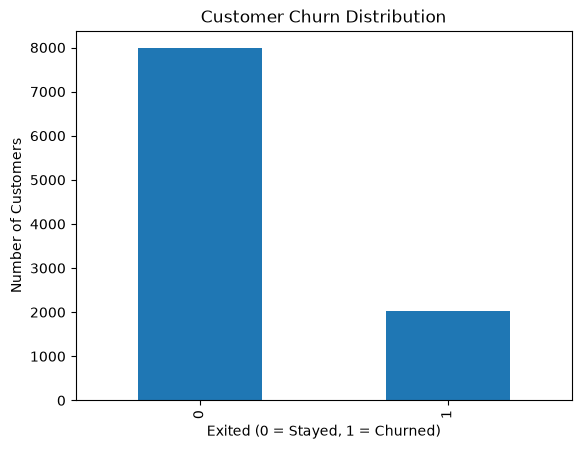

In [74]:
import matplotlib.pyplot as plt

# Count customers who stayed and churned
df["Exited"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()

In [75]:
# Compare average age of stayed and churned customers
df.groupby("Exited")["Age"].mean()
# means Customers who left (churned) → average age ≈ 44.6 years

Exited
0    37.412229
1    44.585868
Name: Age, dtype: float64

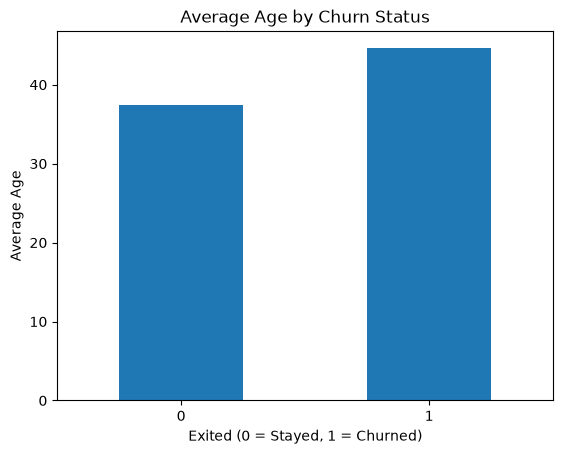

In [76]:
# Compare age distribution for stayed and churned customers

df.groupby("Exited")["Age"].mean().plot(kind="bar")

plt.title("Average Age by Churn Status")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Average Age")
plt.xticks(rotation=0)
plt.show()

In [77]:
# Calculate churn rate for each country
df.groupby("Geography")["Exited"].mean()

Geography
 France     0.146417
 Germany    0.320755
 Spain      0.139073
FRANCE      0.174515
France      0.159292
GERMANY     0.331250
Germany     0.324131
SPAIN       0.191489
Spain       0.165549
Unknown     0.227500
france      0.170000
germany     0.268116
spain       0.198675
Name: Exited, dtype: float64

In [78]:
# data transform
# Convert geography values to the same format
df["Geography"] = df["Geography"].str.strip().str.title()

In [79]:
# Check unique geography categories after cleaning
df["Geography"].value_counts()

Geography
France     4824
Germany    2413
Spain      2382
Unknown     400
Name: count, dtype: int64

In [80]:
# Check all unique Geography values
df["Geography"].unique()

<ArrowStringArray>
['Germany', 'Unknown', 'Spain', 'France']
Length: 4, dtype: str

In [81]:
# Calculate churn rate for each country
df.groupby("Geography")["Exited"].mean()
# germany has highest churn rate 32% 
# That means approximately 32 out of every 100 German customers churned in our dataset.

Geography
France     0.160240
Germany    0.321177
Spain      0.167506
Unknown    0.227500
Name: Exited, dtype: float64

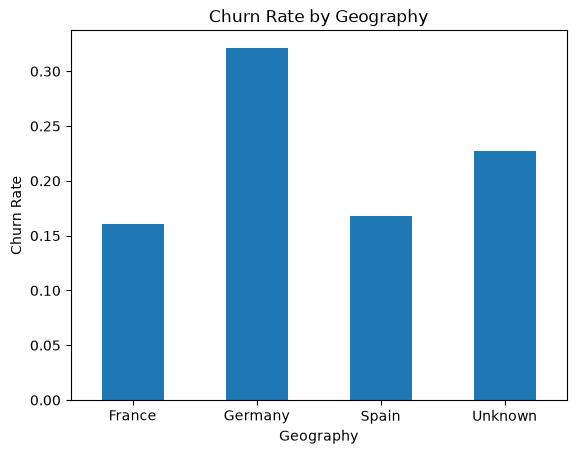

In [82]:
import matplotlib.pyplot as plt

# Calculate churn rate by geography
churn_by_geo = df.groupby("Geography")["Exited"].mean()

# Create bar chart
churn_by_geo.plot(kind="bar")

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

In [83]:
# Calculate churn rate by gender
churn_by_gender = df.groupby("Gender")["Exited"].mean()

churn_by_gender

Gender
 Female     0.262590
 Male       0.173913
FEMALE      0.216216
Female      0.253300
MALE        0.182561
Male        0.161952
Unknown     0.191429
female      0.221818
male        0.189041
Name: Exited, dtype: float64

In [85]:
# data transform
df["Gender"] = df["Gender"].str.strip().str.title()

In [86]:
df["Gender"].unique()

<ArrowStringArray>
['Female', 'Male', 'Unknown']
Length: 3, dtype: str

In [87]:
# Calculate churn rate by gender
churn_by_gender = df.groupby("Gender")["Exited"].mean()

churn_by_gender

Gender
Female     0.249714
Male       0.165974
Unknown    0.191429
Name: Exited, dtype: float64

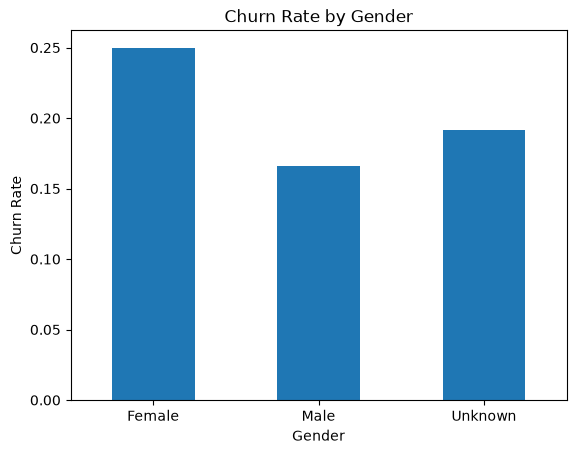

In [88]:
# Visualize churn rate by gender
churn_by_gender.plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

In [89]:
# Calculate churn rate by active membership
df.groupby("IsActiveMember")["Exited"].mean()

IsActiveMember
0    0.268107
1    0.142469
Name: Exited, dtype: float64

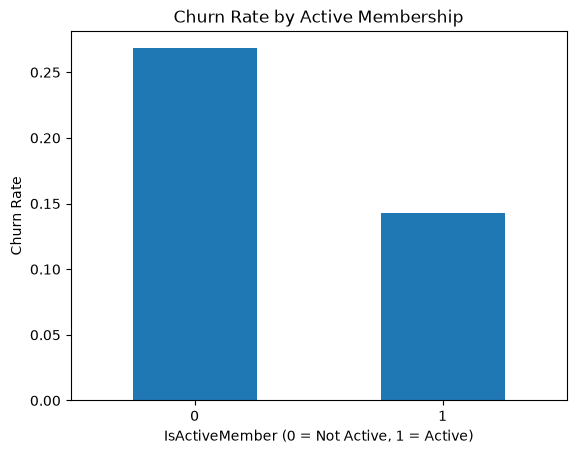

In [90]:
import matplotlib.pyplot as plt

churn_by_active = df.groupby("IsActiveMember")["Exited"].mean()

churn_by_active.plot(kind="bar")

plt.title("Churn Rate by Active Membership")
plt.xlabel("IsActiveMember (0 = Not Active, 1 = Active)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

In [91]:
df.groupby("NumOfProducts")["Exited"].mean()

NumOfProducts
1.0    0.275135
2.0    0.075138
3.0    0.821970
4.0    1.000000
Name: Exited, dtype: float64

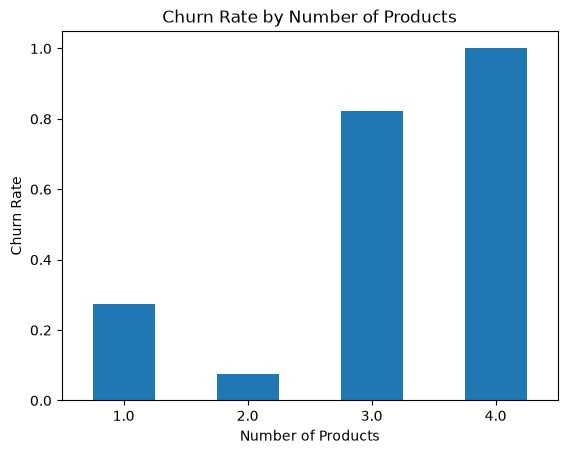

In [92]:
churn_by_products = df.groupby("NumOfProducts")["Exited"].mean()

churn_by_products.plot(kind="bar")

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

In [93]:
df["NumOfProducts"].value_counts().sort_index()
# This shows that customers with 3 or more products are much more likely to leave, especially the 3-product group.
# Customers with 2 products have the lowest churn rate (7.51%).

NumOfProducts
1.0    5172
2.0    4525
3.0     264
4.0      58
Name: count, dtype: int64

In [95]:
df.groupby("Exited")["CreditScore"].mean()
# Customers who stayed had an average credit score of 651.39, while customers who churned had an average score of 645.60. The difference is small, suggesting that credit score alone may not be a strong indicator of customer churn.

Exited
0    651.393059
1    645.603533
Name: CreditScore, dtype: float64

In [96]:
df.groupby("Exited")["Balance"].mean()
#Customers who churned had a higher average account balance (₹91,378) compared to customers who stayed (₹73,335). This suggests that customers with higher balances may have a higher tendency to leave the bank.

Exited
0    73334.998480
1    91378.444269
Name: Balance, dtype: float64

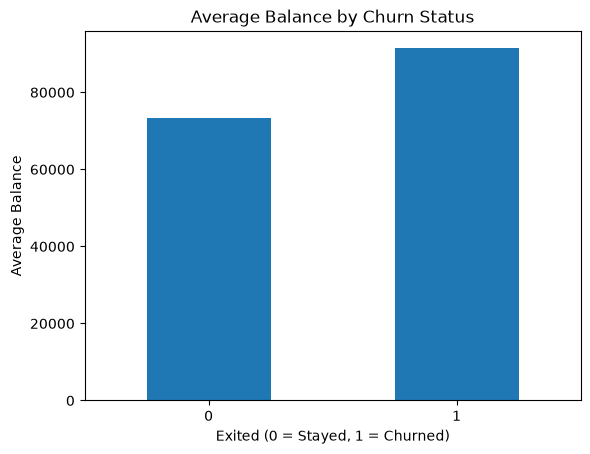

In [97]:
balance_churn = df.groupby("Exited")["Balance"].mean()

balance_churn.plot(kind="bar")

plt.title("Average Balance by Churn Status")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Average Balance")
plt.xticks(rotation=0)
plt.show()

In [98]:
# next part data processing

In [99]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure ', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [101]:
# remove unnecessary col 
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [102]:
df.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,608.0,Germany,Female,48.0,2.0,127924.25,2.0,1.0,0,100168.24,0
1,654.0,Germany,Male,37.0,5.0,112146.12,1.0,1.0,0,75927.35,0
2,651.0,Unknown,Male,47.0,5.0,156265.31,2.0,0.0,0,1055.66,0
3,639.0,Spain,Male,38.0,9.0,130233.14,1.0,1.0,1,81861.10,0
4,485.0,France,Female,25.0,3.0,134467.26,1.0,1.0,1,113266.09,0
5,590.0,Spain,Female,44.0,3.0,139432.37,1.0,1.0,0,62222.81,0
6,484.0,Germany,Male,54.0,5.0,134388.11,1.0,0.0,0,49954.79,1
7,530.0,Spain,Female,37.0,7.0,0.00,2.0,1.0,0,104170.48,0
8,523.0,Germany,Male,60.0,1.0,163894.35,1.0,0.0,1,57061.71,0
9,592.0,France,Female,38.0,8.0,119278.01,2.0,0.0,1,19370.73,0


In [103]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [104]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10019, 10)
y shape: (10019,)


In [106]:
# which col are categorical
X.select_dtypes(include="object").columns

C:\Users\DELL\AppData\Local\Temp\ipykernel_12536\1256584501.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['Geography', 'Gender'], dtype='str')

In [107]:
# convert text into num like geography , gender (use one hot encoding)
X = pd.get_dummies(X, columns=["Geography", "Gender"], dtype=int)
X.head(10)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Geography_Unknown,Gender_Female,Gender_Male,Gender_Unknown
0,608.0,48.0,2.0,127924.25,2.0,1.0,0,100168.24,0,1,0,0,1,0,0
1,654.0,37.0,5.0,112146.12,1.0,1.0,0,75927.35,0,1,0,0,0,1,0
2,651.0,47.0,5.0,156265.31,2.0,0.0,0,1055.66,0,0,0,1,0,1,0
3,639.0,38.0,9.0,130233.14,1.0,1.0,1,81861.10,0,0,1,0,0,1,0
4,485.0,25.0,3.0,134467.26,1.0,1.0,1,113266.09,1,0,0,0,1,0,0
5,590.0,44.0,3.0,139432.37,1.0,1.0,0,62222.81,0,0,1,0,1,0,0
6,484.0,54.0,5.0,134388.11,1.0,0.0,0,49954.79,0,1,0,0,0,1,0
7,530.0,37.0,7.0,0.00,2.0,1.0,0,104170.48,0,0,1,0,1,0,0
8,523.0,60.0,1.0,163894.35,1.0,0.0,1,57061.71,0,1,0,0,0,1,0
9,592.0,38.0,8.0,119278.01,2.0,0.0,1,19370.73,1,0,0,0,1,0,0


In [108]:
# split data (training and testing data)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [109]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8015, 15)
X_test: (2004, 15)
y_train: (8015,)
y_test: (2004,)


In [110]:
# ml model

In [111]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [112]:
y_pred = model.predict(X_test)

In [114]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.812874251497006

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1596
           1       0.63      0.19      0.29       408

    accuracy                           0.81      2004
   macro avg       0.73      0.58      0.59      2004
weighted avg       0.79      0.81      0.77      2004



In [115]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [116]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [117]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8502994011976048

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1596
           1       0.75      0.39      0.52       408

    accuracy                           0.85      2004
   macro avg       0.81      0.68      0.71      2004
weighted avg       0.84      0.85      0.83      2004



In [118]:
rf_balanced = RandomForestClassifier( # this model we select
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [119]:
rf_balanced_pred = rf_balanced.predict(X_test)

print(rf_balanced_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


In [120]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_balanced_pred)

print(cm)

[[1447  149]
 [ 192  216]]


In [121]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, rf_balanced_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_balanced_pred))

Accuracy: 0.8298403193612774

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      1596
           1       0.59      0.53      0.56       408

    accuracy                           0.83      2004
   macro avg       0.74      0.72      0.73      2004
weighted avg       0.82      0.83      0.83      2004



In [122]:
print(X.columns.tolist())

['CreditScore', 'Age', 'Tenure ', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Geography_Unknown', 'Gender_Female', 'Gender_Male', 'Gender_Unknown']


In [123]:
customer = {
    "CreditScore": 650,
    "Age": 40,
    "Tenure ": 5,
    "Balance": 80000,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 1,
    "EstimatedSalary": 100000,
    "Geography": "Germany",
    "Gender": "Female"
}

customer_df = pd.DataFrame([customer])

customer_df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography,Gender
0,650,40,5,80000,2,1,1,100000,Germany,Female


In [124]:
customer_df = pd.get_dummies(
    customer_df,
    columns=["Geography", "Gender"],
    dtype=int
)

customer_df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Gender_Female
0,650,40,5,80000,2,1,1,100000,1,1


In [125]:
customer_df = customer_df.reindex(columns=X.columns, fill_value=0)

customer_df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Geography_Unknown,Gender_Female,Gender_Male,Gender_Unknown
0,650,40,5,80000,2,1,1,100000,0,1,0,0,1,0,0


In [126]:
prediction = rf_balanced.predict(customer_df)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("🚨 Customer is likely to CHURN")
else:
    print("✅ Customer is likely to STAY")

Prediction: 1
🚨 Customer is likely to CHURN


In [127]:
# function
def predict_churn(
    credit_score,
    age,
    tenure,
    balance,
    num_products,
    has_cr_card,
    is_active_member,
    estimated_salary,
    geography,
    gender
):
    customer = {
        "CreditScore": credit_score,
        "Age": age,
        "Tenure ": tenure,
        "Balance": balance,
        "NumOfProducts": num_products,
        "HasCrCard": has_cr_card,
        "IsActiveMember": is_active_member,
        "EstimatedSalary": estimated_salary,
        "Geography": geography,
        "Gender": gender
    }

    customer_df = pd.DataFrame([customer])

    customer_df = pd.get_dummies(
        customer_df,
        columns=["Geography", "Gender"],
        dtype=int
    )

    customer_df = customer_df.reindex(
        columns=X.columns,
        fill_value=0
    )

    prediction = rf_balanced.predict(customer_df)

    if prediction[0] == 1:
        return "🚨 Customer is likely to CHURN"
    else:
        return "✅ Customer is likely to STAY"

In [129]:
predict_churn(
    650,       # Credit Score
    40,        # Age
    5,         # Tenure
    80000,     # Balance
    2,         # Number of Products
    0,         # Has Credit Card (1 = Yes)
    0,         # Active Member (1 = Yes)
    100000,    # Estimated Salary
    "Germany", # Geography
    "Female"   # Gender
)

'✅ Customer is likely to STAY'

In [130]:
#save model
import joblib

joblib.dump(rf_balanced, "customer_churn_model.joblib")

print("Model saved successfully!")

Model saved successfully!


In [131]:
# Save the feature columns
joblib.dump(X.columns.tolist(), "training_columns.pkl")

print("Training columns saved successfully!")

Training columns saved successfully!


In [132]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\DELL
['.agents', '.anaconda', '.android', '.cache', '.conda', '.continuum', '.copilot', '.cursor', '.git-for-windows-updater', '.gitconfig', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.packettracer', '.streamlit', '.vscode', '.vscode-shared', 'AndroidStudioProjects', 'AppData', 'Application Data', 'churn-prediction.ipynb', 'Cisco Packet Tracer 9.0.0', 'Contacts', 'Cookies', 'customer-churn.ipynb', 'customer_churn_model.joblib', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'finxing_style', 'housing.csv', 'icons', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{f0d2e612-e457-11ef-9dc1-f23cfe78ad3a}.TM.blf', 'NTUSER.DAT{f0d2e612-e457-11ef-9dc1-f23cfe78ad3a}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{f0d2e612-e457-11ef-9dc1-f23cfe78ad3a}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'PycharmPr